<a href="https://colab.research.google.com/github/ilyastars/CP-Hactiv8-Rice-Production-Analysis/blob/main/RAG_Llama_AVPN_IT_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG (Retrieval-Augmented Generation) dengan LangChain & LangGraph

## Apa itu RAG?

LLM seperti Llama atau Gemini punya pengetahuan yang terbatas pada data training-nya. Mereka tidak tahu:
- Dokumen internal perusahaan kamu
- Data terbaru setelah tanggal cutoff
- Informasi spesifik yang tidak ada di internet

**RAG** adalah teknik untuk mengatasi ini. Alih-alih mengandalkan memori model, kita ambil informasi yang relevan dari database dulu, lalu kirimkan ke model sebagai konteks.

### Arsitektur RAG

```
Dokumen PDF/Text
      ↓
   Chunking          ← potong jadi bagian kecil
      ↓
   Embedding         ← ubah teks jadi vector angka
      ↓
  Vector Store       ← simpan di FAISS
      ↓
User tanya sesuatu
      ↓
  Retrieve           ← cari chunk yang paling relevan
      ↓
  Generate           ← kirim chunk + pertanyaan ke LLM
      ↓
   Jawaban
```

### Yang akan kita bangun di notebook ini:

1. **Vector Database** dengan FAISS — simpan dan cari dokumen berdasarkan kemiripan semantik
2. **RAG Pipeline** dengan LangGraph — alur retrieve → generate yang terstruktur


## Setup & Instalasi

Package yang kita butuhkan:
- `langchain`, `langchain-community`, `langchain-text-splitters` — framework utama
- `langchain-google-genai` — untuk Google Embedding
- `langchain-groq` — untuk LLM Llama via Groq
- `faiss-cpu` — vector database
- `PyMuPDF` — baca file PDF
- `langgraph` — orkestrasi alur RAG


In [ ]:
!pip install -qU langchain langchain-community langchain-text-splitters faiss-cpu langchain-google-genai PyMuPDF langchain-groq langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.1/113.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

# Part 1: Vector Database dengan FAISS

## Apa itu Embedding?

Embedding adalah proses mengubah teks menjadi deretan angka (vector) yang merepresentasikan makna teks tersebut.

```
"Saya suka makan nasi goreng"  →  [0.12, -0.34, 0.87, 0.03, ...]  (768 angka)
"I love fried rice"            →  [0.11, -0.31, 0.85, 0.02, ...]  (mirip!)
"Harga saham naik hari ini"    →  [-0.55, 0.22, -0.14, 0.91, ...]  (jauh berbeda)
```

Teks yang maknanya mirip akan menghasilkan vector yang "dekat" satu sama lain di ruang vektor.
Inilah yang memungkinkan pencarian semantik — kita tidak mencari keyword, tapi mencari makna.

## Apa itu FAISS?

**FAISS** (Facebook AI Similarity Search) adalah library untuk menyimpan dan mencari vector secara efisien.
Kita bisa memasukkan ribuan dokumen, lalu mencari dokumen yang paling mirip dengan query dalam hitungan milidetik.


## Inisialisasi Embedding & FAISS

Kita pakai `gemini-embedding-2` dari Google sebagai model embedding.
Model ini mengubah setiap teks menjadi vector 768 dimensi.


In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
import os
from google.colab import userdata

# Simpan API key di: Colab Secrets (🔑) → nama secret: GEMINI
GEMINI = userdata.get('GEMINI')
os.environ["GOOGLE_API_KEY"] = GEMINI

# text-embedding-004 adalah model embedding terbaru dari Google
# menghasilkan vector 768 dimensi per teks
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2", output_dimensionality=768)

In [ ]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

# embed_query("hello world") menghasilkan vector — kita ambil panjangnya
# untuk menentukan dimensi index FAISS
# IndexFlatL2 = cari vector terdekat dengan jarak Euclidean (L2)
index = faiss.IndexFlatL2(len(embeddings.embed_query("hello world")))

# Inisialisasi FAISS Vector Store
vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),  # simpan dokumen di memori (bukan disk)
    index_to_docstore_id={},      # mapping index FAISS ke ID dokumen
)

## Tambah Dokumen ke Vector Store

Setiap dokumen direpresentasikan sebagai objek `Document` yang punya dua field:
- `page_content` — isi teks dokumen
- `metadata` — informasi tambahan (bisa dipakai untuk filtering)


In [ ]:
from uuid import uuid4
from langchain_core.documents import Document

document_1 = Document(
    page_content="I had chocolate chip pancakes and scrambled eggs for breakfast this morning.",
    metadata={"source": "tweet"},
)
document_2 = Document(
    page_content="The weather forecast for tomorrow is cloudy and overcast, with a high of 62 degrees.",
    metadata={"source": "news"},
)
document_3 = Document(
    page_content="Building an exciting new project with LangChain - come check it out!",
    metadata={"source": "tweet"},
)
document_4 = Document(
    page_content="Robbers broke into the city bank and stole $1 million in cash.",
    metadata={"source": "news"},
)
document_5 = Document(
    page_content="Wow! That was an amazing movie. I can't wait to see it again.",
    metadata={"source": "tweet"},
)
document_6 = Document(
    page_content="Is the new iPhone worth the price? Read this review to find out.",
    metadata={"source": "website"},
)
document_7 = Document(
    page_content="The top 10 soccer players in the world right now.",
    metadata={"source": "website"},
)
document_8 = Document(
    page_content="LangGraph is the best framework for building stateful, agentic applications!",
    metadata={"source": "tweet"},
)
document_9 = Document(
    page_content="The stock market is down 500 points today due to fears of a recession.",
    metadata={"source": "news"},
)
document_10 = Document(
    page_content="I have a bad feeling I am going to get deleted :(",
    metadata={"source": "tweet"},
)

documents = [document_1, document_2, document_3, document_4, document_5,
             document_6, document_7, document_8, document_9, document_10]

# UUID dipakai sebagai ID unik untuk setiap dokumen
uuids = [str(uuid4()) for _ in range(len(documents))]

vector_store.add_documents(documents=documents, ids=uuids)

['db5ec457-85f2-4071-8fff-11501d32e1c0',
 '0b953b66-e520-4724-875b-d8ff95e69491',
 '5dfcf6a4-7d43-49cb-8485-4de5d23dc251',
 '43e9485f-a4d4-4852-a5b1-92bb03bc4c7b',
 'd16c3c3e-de56-4e76-8666-4c52e98d825c',
 'ebb97c27-8a73-4544-be4b-b494f819f94b',
 '5417fa4f-a46d-42a6-a984-c82d3c42fb05',
 'bc4ea783-8794-4ccc-990c-956895978500',
 '78d954af-9152-4a6b-87c9-323f8e938d1c',
 'efcecad0-5181-4884-b1ee-7f94bcdbf10d']

## Pencarian di FAISS

FAISS mendukung dua jenis pencarian:

**1. Similarity Search** — cari dokumen paling mirip dengan query secara semantik

**2. Similarity Search dengan Filter** — sama seperti di atas, tapi disaring berdasarkan metadata

Filter dihandle oleh layer LangChain (bukan FAISS langsung, karena FAISS sendiri tidak punya fitur metadata filtering).
Operator yang didukung:

| Operator | Arti |
|---|---|
| `$eq` | sama dengan |
| `$neq` | tidak sama dengan |
| `$gt` / `$lt` | lebih besar / lebih kecil |
| `$gte` / `$lte` | lebih besar atau sama / lebih kecil atau sama |
| `$in` | ada di dalam list |
| `$nin` | tidak ada di dalam list |
| `$and` | semua kondisi harus terpenuhi |
| `$or` | salah satu kondisi terpenuhi |
| `$not` | negasi kondisi |


In [ ]:
# Cari 2 dokumen paling mirip dengan query, tapi hanya dari sumber 'tweet'
results = vector_store.similarity_search(
    "LangChain provides abstractions to make working with LLMs easy",
    k=2,
    filter={"source": {"$eq": "tweet"}},
)
for res in results:
    print(f"* {res.page_content} [{res.metadata}]")

* Building an exciting new project with LangChain - come check it out! [{'source': 'tweet'}]
* LangGraph is the best framework for building stateful, agentic applications! [{'source': 'tweet'}]


In [ ]:
# Cari tanpa filter — dari semua sumber
results = vector_store.similarity_search(
    "The new iPhone",
    k=2,
)
for res in results:
    print(f"* {res.page_content} [{res.metadata}]")

* Is the new iPhone worth the price? Read this review to find out. [{'source': 'website'}]
* I have a bad feeling I am going to get deleted :( [{'source': 'tweet'}]


## Simpan dan Muat FAISS Index

FAISS bisa disimpan ke disk agar tidak perlu embed ulang setiap kali program dijalankan.

In [ ]:
# Simpan index ke folder lokal
vector_store.save_local("faiss_index")

In [ ]:
# Muat kembali dari disk
# allow_dangerous_deserialization=True diperlukan karena FAISS menggunakan pickle
new_vector_store = FAISS.load_local(
    "faiss_index", embeddings, allow_dangerous_deserialization=True
)

docs = new_vector_store.similarity_search("qux")
for res in docs:
    print(f"* {res.page_content} [{res.metadata}]")

* I have a bad feeling I am going to get deleted :( [{'source': 'tweet'}]
* Wow! That was an amazing movie. I can't wait to see it again. [{'source': 'tweet'}]
* Building an exciting new project with LangChain - come check it out! [{'source': 'tweet'}]
* The stock market is down 500 points today due to fears of a recession. [{'source': 'news'}]


# Part 2: RAG Pipeline dengan LangChain & LangGraph

Sekarang kita bangun RAG yang sesungguhnya — membaca dokumen PDF, menyimpannya ke FAISS,
lalu menjawab pertanyaan berdasarkan isi dokumen tersebut.

## Mengapa LangGraph?

LangGraph memungkinkan kita mendefinisikan alur RAG sebagai **graph** dengan node dan edge yang jelas.
Ini lebih terstruktur dibanding chain biasa karena:
- Mudah divisualisasikan
- Mudah ditambah node baru (misal: reranking, self-reflection)
- State dikelola secara eksplisit — setiap node tahu apa yang sudah dikerjakan node sebelumnya

Alur yang akan kita buat:
```
START → retrieve → generate → END
```


In [ ]:
from langchain_text_splitters import CharacterTextSplitter
from langchain_core.documents import Document
import fitz  # PyMuPDF

### Langkah 1: Extract dan Chunk Dokumen

**Mengapa perlu chunking?**

LLM punya batas token — kita tidak bisa memasukkan seluruh isi dokumen 100 halaman sekaligus.
Selain itu, semakin panjang konteks yang dikirim, semakin lambat dan mahal responsnya.

Dengan chunking, dokumen dipotong jadi bagian-bagian kecil. Saat user bertanya, kita hanya ambil
chunk yang paling relevan — bukan seluruh dokumen.

**Parameter chunking:**
- `chunk_size=1000` — maksimal 1000 karakter per chunk. Makin kecil = makin presisi tapi lebih banyak chunk
- `chunk_overlap=200` — 200 karakter terakhir chunk sebelumnya diulang di chunk berikutnya,
  agar informasi di batas potongan tidak hilang
- `separator="\n"` — potong di newline dulu sebelum memotong berdasarkan panjang

**Dokumen CV dapat diakses dan didownload [disini](https://drive.google.com/file/d/11cucT4zgOyvmkjkikCUWSCg1DiPTRb1J/view?usp=sharing)**

In [ ]:
def extract_text_from_pdf(pdf_path):
    """Mengekstrak teks dari PDF menggunakan PyMuPDF"""
    doc = fitz.open(pdf_path)
    text = "\n".join([page.get_text() for page in doc])
    return text

# Ganti path ini dengan PDF kamu
pdf_text = extract_text_from_pdf("/content/Rizky_Andika_CV.pdf")
print(f"Total karakter: {len(pdf_text)}")
print("\nPreview 500 karakter pertama:")
print(pdf_text[:500])

Total karakter: 3049

Preview 500 karakter pertama:
Rizky Andika Pratama
Data Scientist & Machine Learning Engineer
rizky.andika@email.com  |  +62 813-5678-9012  |  linkedin.com/in/rizkyandika  |  github.com/rizkyandika
PROFESSIONAL SUMMARY
Data Scientist with 6 years of experience transforming complex business problems into data-driven solutions.
Specialized in machine learning, NLP, and MLOps with a strong background in the e-commerce and fintech industries.
Proven track record of deploying production-grade ML models that directly impact revenu


In [ ]:
splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1000,
    chunk_overlap=200
)

chunks = splitter.split_text(pdf_text)
print(f"Total chunks: {len(chunks)}")

Total chunks: 4


In [ ]:
# Preview setiap chunk (100 karakter pertama saja)
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}: {chunk[:100]}...")

Chunk 1: Rizky Andika Pratama
Data Scientist & Machine Learning Engineer
rizky.andika@email.com  |  +62 813-5...
Chunk 2: Graduated: A
Machine Learning Engineering Bootcamp -- Hacktiv8 (2019)
9-week intens
deployment.
WORK...
Chunk 3: - Built a credit scoring model for OVO PayLater using XGBoost and LightGBM achieving AUC-ROC of 0.89...
Chunk 4: stakeholders.
- Conducted ad-hoc analyses supporting quarterly OKR reviews for the COO office.
TECHN...


### Langkah 2: Upload Chunk ke Vector Store

Setelah dokumen di-chunk, kita embed dan simpan ke FAISS.
Proses ini hanya dilakukan sekali — hasilnya disimpan ke disk agar bisa dimuat ulang.


In [ ]:
# Inisialisasi FAISS baru untuk dokumen PDF ini
index = faiss.IndexFlatL2(len(embeddings.embed_query("hello world")))

vector_store = FAISS(
    embedding_function=embeddings,
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

In [ ]:
# Bungkus setiap chunk sebagai Document object
documents = [Document(page_content=chunk) for chunk in chunks]

# Generate UUID untuk setiap dokumen
uuids = [str(uuid4()) for _ in range(len(documents))]

# Embed dan simpan ke FAISS
vector_store.add_documents(documents=documents, ids=uuids)
print(f"{len(documents)} chunks berhasil disimpan ke vector store")

4 chunks berhasil disimpan ke vector store


In [ ]:
# Simpan ke disk agar tidak perlu embed ulang
vector_store.save_local("faiss_index")
print("Index tersimpan di folder faiss_index/")

Index tersimpan di folder faiss_index/


### Langkah 3: Bangun RAG dengan LangGraph

Kita definisikan tiga komponen utama:

**1. State** — objek yang membawa data antar node di graph. Berisi:
- `question` — pertanyaan dari user
- `context` — dokumen yang diambil dari FAISS
- `answer` — jawaban final dari LLM

**2. Node `retrieve`** — ambil chunk relevan dari FAISS berdasarkan pertanyaan

**3. Node `generate`** — kirim pertanyaan + chunk ke LLM untuk dijawab


In [ ]:
from langchain_core.documents import Document
from typing import List, TypedDict
from langchain_groq import ChatGroq

# State adalah "tas" yang dibawa sepanjang perjalanan graph
# Setiap node bisa membaca dan mengisi field di State
class State(TypedDict):
    question: str           # pertanyaan dari user
    context: List[Document] # hasil retrieve dari FAISS
    answer: str             # jawaban final dari LLM

#### RAG Prompt

Kita pakai prompt standar dari LangChain Hub (`rlm/rag-prompt`).
Prompt ini sudah dirancang khusus untuk RAG — menginstruksikan model untuk hanya menjawab
berdasarkan konteks yang diberikan, dan mengatakan "saya tidak tahu" jika informasinya tidak ada.

Kita bisa print isinya untuk melihat template-nya.


In [ ]:
from langchain_classic import hub

# Tarik prompt RAG standar dari LangChain Hub
# Prompt ini punya dua variabel: {context} dan {question}
prompt = hub.pull("rlm/rag-prompt")

# Lihat isi prompt-nya
example_messages = prompt.invoke(
    {"context": "(context goes here)", "question": "(question goes here)"}
).to_messages()

assert len(example_messages) == 1
print("Isi RAG prompt:")
print(example_messages[0].content)

Isi RAG prompt:
You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: (question goes here) 
Context: (context goes here) 
Answer:


### Cara Mendapatkan Groq API Key

**Groq** adalah platform inference yang menyediakan akses gratis ke model open-source seperti Llama, Mixtral, dan Gemma dengan kecepatan sangat tinggi (ratusan token per detik).

####Langkah-langkah:

1. Buka [https://console.groq.com](https://console.groq.com) dan buat akun (bisa pakai Google)
2. Setelah login, klik menu **API Keys** di sidebar kiri
3. Klik **Create API Key**, beri nama, lalu copy key-nya
4. Di Google Colab, klik ikon 🔑 **(Secrets)** di sidebar kiri
5. Klik **Add new secret** dengan pengaturan:
   - Name: `GROQ_API_KEY`
   - Value: paste API key kamu
6. Aktifkan toggle **Notebook access**

Setelah itu, ganti baris `os.environ` dengan cara yang lebih aman:

```python
from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
```

> **Catatan**: Groq menyediakan free tier dengan rate limit yang cukup untuk eksperimen.
> Untuk melihat daftar model yang tersedia, cek [https://console.groq.com/docs/models](https://console.groq.com/docs/models)

In [ ]:
# Inisialisasi LLM — pakai Llama 3.3 70B via Groq (gratis, cepat)
# Groq menyediakan inference engine yang sangat cepat untuk model open-source

from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

MODEL = 'llama-3.3-70b-versatile'

llm = ChatGroq(
    temperature=0,  # 0 = deterministik, cocok untuk Q&A faktual
    model=MODEL     # bisa diganti model lain seperti gemini atau GPT
)

In [ ]:
# Node 1: Retrieve — ambil dokumen relevan dari FAISS
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


# Node 2: Generate — buat jawaban berdasarkan context + question
def generate(state: State):
    # Gabungkan semua chunk yang diambil jadi satu string konteks
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    # Isi template prompt dengan konteks dan pertanyaan
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    # Kirim ke LLM
    response = llm.invoke(messages)
    return {"answer": response.content}

In [ ]:
from langgraph.graph import START, StateGraph

# Definisikan graph: retrieve dulu, lalu generate
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

print("Graph berhasil dikompilasi!")

Graph berhasil dikompilasi!


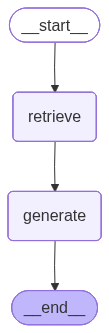

In [ ]:
# Visualisasi alur graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Jalankan RAG

Sekarang kita bisa bertanya tentang isi dokumen PDF yang sudah kita upload.
LLM akan menjawab hanya berdasarkan konten dokumen — bukan dari pengetahuan umumnya.


In [ ]:
result = graph.invoke({"question": "Who is Rizky Andika?"})

print("=== Context yang diambil dari FAISS ===")
for i, doc in enumerate(result["context"]):
    print(f"\nChunk {i+1}:")
    print(doc.page_content[:200] + "...")

print("\n=== Jawaban LLM ===")
print(result["answer"])

=== Context yang diambil dari FAISS ===

Chunk 1:
Rizky Andika Pratama
Data Scientist & Machine Learning Engineer
rizky.andika@email.com  |  +62 813-5678-9012  |  linkedin.com/in/rizkyandika  |  github.com/rizkyandika
PROFESSIONAL SUMMARY
Data Scient...

Chunk 2:
stakeholders.
- Conducted ad-hoc analyses supporting quarterly OKR reviews for the COO office.
TECHNICAL SKILLS
Programming
: Python (advanced), SQL (advanced), R, Bash
ML / AI
SELECTED PROJECTS
RAG-b...

Chunk 3:
- Built a credit scoring model for OVO PayLater using XGBoost and LightGBM achieving AUC-ROC of 0.89,
enabling 200,000 new credit approvals.
- Developed a real-time fraud detection system processing 3...

Chunk 4:
Graduated: A
Machine Learning Engineering Bootcamp -- Hacktiv8 (2019)
9-week intens
deployment.
WORK EXPERIENCE
Senior Data Scientist -- Shopee Indonesia  (March 2022 - Present)
- Led a team of 4 data...

=== Jawaban LLM ===
Rizky Andika is a Data Scientist and Machine Learning Engineer with 6 years of expe

In [ ]:
result = graph.invoke({"question": "When and where is Rizky Andika graduated?"})
print(f'Answer: {result["answer"]}')

Answer: Rizky Andika graduated from Institut Pertanian Bogor (IPB University) with a Bachelor of Science in Statistics. The context does not provide the exact date of graduation. Additionally, he graduated from a 9-week Machine Learning Engineering Bootcamp at Hacktiv8 in 2019.
